# Symbolic Knowledge Discovery - WineDataset (raw data)

This notebook follows the workflow style from:
- `resources/FCA_From_Scratch_SymbolicKD.ipynb`
- `resources/SymbolicKD_Pattern_Mining_+_Clustering.ipynb`

The run is intentionally lightweight to avoid computationally heavy processing:
- full binary-context mining with `caspailleur`
- sampled pattern-space mining with `paspailleur` for subgroup exploration


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/wine_symbolic_kd_raw_light")
summary = json.loads((OUTPUT_DIR / "summary.json").read_text(encoding="utf-8"))
summary


{'dataset': 'wine',
 'n_objects': 1290,
 'n_binary_features': 65,
 'caspailleur_concepts': 1550,
 'caspailleur_implications': 179,
 'pattern_structure_shape': [10, 45],
 'subgroup_files': {'high_price_quartile': 'subgroups_high_price_quartile.csv'},
 'subgroup_rationale': {'high_price_quartile': 'Price in top quartile (>= 38.49) captures commercially premium wines.'},
 'year_grouping_justification': 'Year-based subgrouping uses broader eras (<=2010 vs >2010) instead of consecutive pairs to reduce sparsity and improve interpretability.'}

## 1) Context and Dataset Overview

We mine a binary context for FCA (caspailleur) and a compact multi-dimensional pattern structure for subgroup-oriented exploration (paspailleur).


In [2]:
context = pd.read_csv(OUTPUT_DIR / "binary_context.csv")
concepts = pd.read_csv(OUTPUT_DIR / "caspailleur_concepts.csv")
implications = pd.read_csv(OUTPUT_DIR / "caspailleur_implications.csv")
feature_importance = pd.read_csv(OUTPUT_DIR / "feature_importance.csv")
interesting_implications = pd.read_csv(OUTPUT_DIR / "interesting_implications.csv")
paspailleur_concepts = pd.read_csv(OUTPUT_DIR / "paspailleur_concepts.csv")

print("Context shape:", context.shape)
print("Caspailleur concepts:", len(concepts))
print("Caspailleur implications:", len(implications))
print("Paspailleur concepts (sampled pattern structure):", len(paspailleur_concepts))


Context shape: (1290, 66)
Caspailleur concepts: 1550
Caspailleur implications: 179
Paspailleur concepts (sampled pattern structure): 244


## 2) Feature Importance (more important vs less important)

Importance combines:
- binary support (frequency)
- stability-weighted concept participation
- implication participation weight


,feature,support_ratio,concept_weight,implication_weight,importance_score
0,Closure_Natural Cork,0.646512,1381.236434,1.655504,1383.538450
1,region_clean_Other,0.563566,1030.013178,0.692093,1031.268837
2,Type_White,0.452713,766.396124,2.516899,769.365736
3,Type_Red,0.441085,655.020155,2.010233,657.471473
4,abv_num_low,0.447287,637.511628,1.013643,638.972558
5,vintage_year_low,0.400775,415.708527,0.782016,416.891318
6,Style_Other,0.382946,413.586047,0.484341,414.453333
7,Country_France,0.389147,379.843411,2.116899,382.349457
8,price_num_low,0.348837,343.573643,0.264186,344.186667
9,abv_num_mid,0.340310,318.550388,0.660465,319.551163


,feature,support_ratio,concept_weight,implication_weight,importance_score
50,region_clean_Bordeaux,0.051938,1.675969,0.219535,1.947442
51,region_clean_Marlborough,0.050388,1.201550,0.132093,1.384031
52,region_clean_South Australia,0.043411,0.607752,0.052093,0.703256
53,region_clean_Loire,0.045736,0.594574,0.054884,0.695194
54,region_clean_Rhône,0.037984,0.000000,0.045581,0.083566
55,Country_USA,0.039535,0.039535,0.000000,0.079070
56,Closure_Synthetic Cork,0.018605,0.000000,0.000000,0.018605
57,Closure_Unknown,0.008527,0.000000,0.000000,0.008527
58,abv_num_missing,0.006977,0.000000,0.000000,0.006977
59,Closure_Vinolok,0.005426,0.000000,0.000000,0.005426


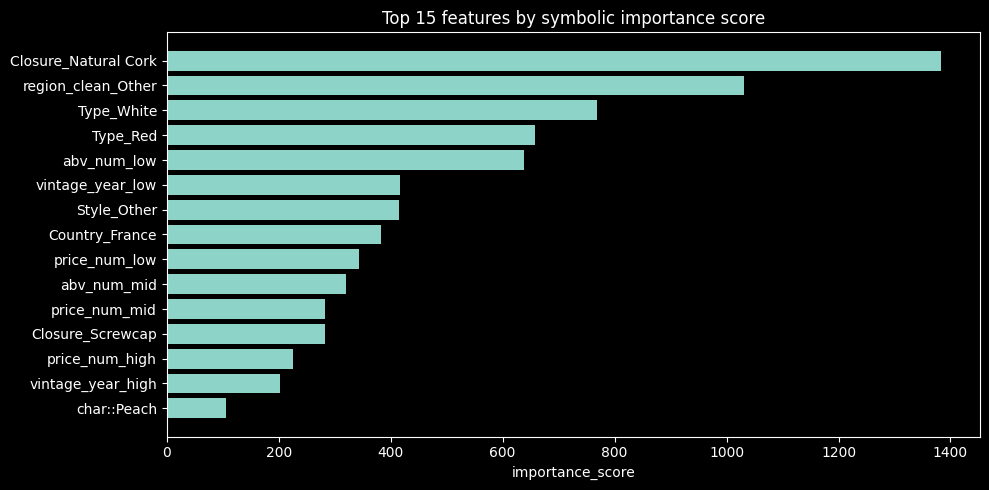

In [3]:
top_features = feature_importance.head(15).copy()
low_features = feature_importance.tail(15).copy()

display(top_features)
display(low_features)

plt.figure(figsize=(10, 5))
plt.barh(top_features["feature"][::-1], top_features["importance_score"][::-1])
plt.title("Top 15 features by symbolic importance score")
plt.xlabel("importance_score")
plt.tight_layout()
plt.show()


## 3) Concepts (including cool/stable concepts)

`caspailleur` returns concept intents/extents with support and delta stability.
We inspect high-support and high-stability concepts.


In [4]:
stable_concepts = concepts.sort_values(["delta_stability", "support"], ascending=[False, False]).head(20)
support_concepts = concepts.sort_values("support", ascending=False).head(20)

display(stable_concepts)
display(support_concepts)


,extent,intent,support,delta_stability
0,"{'wine_0918', 'wine_1134', 'wine_1276', 'wine_...",set(),1290,456
1,"{'wine_0918', 'wine_1104', 'wine_1134', 'wine_...",{'Closure_Natural Cork'},834,396
2,"{'wine_0918', 'wine_0340', 'wine_0107', 'wine_...",{'region_clean_Other'},727,289
3,"{'wine_1134', 'wine_0871', 'wine_0107', 'wine_...",{'Type_White'},584,210
4,"{'wine_1134', 'wine_0871', 'wine_0107', 'wine_...",{'abv_num_low'},577,203
5,"{'wine_1134', 'wine_1104', 'wine_0871', 'wine_...","{'Closure_Natural Cork', 'Country_France'}",418,193
6,"{'wine_0918', 'wine_0340', 'wine_0312', 'wine_...","{'Closure_Natural Cork', 'region_clean_Other'}",438,176
7,"{'wine_1134', 'wine_0871', 'wine_0107', 'wine_...","{'Type_White', 'abv_num_low'}",374,167
8,"{'wine_0918', 'wine_1104', 'wine_0340', 'wine_...",{'abv_num_mid'},439,164
9,"{'wine_0918', 'wine_1104', 'wine_0340', 'wine_...",{'Type_Red'},569,154


,extent,intent,support,delta_stability
0,"{'wine_0918', 'wine_1134', 'wine_1276', 'wine_...",set(),1290,456
1,"{'wine_0918', 'wine_1104', 'wine_1134', 'wine_...",{'Closure_Natural Cork'},834,396
2,"{'wine_0918', 'wine_0340', 'wine_0107', 'wine_...",{'region_clean_Other'},727,289
3,"{'wine_1134', 'wine_0871', 'wine_0107', 'wine_...",{'Type_White'},584,210
4,"{'wine_1134', 'wine_0871', 'wine_0107', 'wine_...",{'abv_num_low'},577,203
9,"{'wine_0918', 'wine_1104', 'wine_0340', 'wine_...",{'Type_Red'},569,154
22,"{'wine_0918', 'wine_1134', 'wine_0871', 'wine_...",{'vintage_year_low'},517,114
37,"{'wine_1134', 'wine_1104', 'wine_0871', 'wine_...",{'Country_France'},502,84
11,"{'wine_0871', 'wine_0340', 'wine_1276', 'wine_...",{'Style_Other'},494,147
20,"{'wine_1104', 'wine_0107', 'wine_0584', 'wine_...",{'price_num_low'},450,122


## 4) Implications (highlight interesting ones)

The table below shows a compact ranked set of implications to discuss (3-5 most interesting).


,premise,conclusion,support,delta_stability,premise_len,conclusion_len,interesting_score
0,"{'char::Black Fruit', 'region_clean_Other'}",{'Type_Red'},135,34,2,1,209.25
1,{'Style_Savoury & Full Bodied'},{'Type_Red'},154,14,1,1,207.90
2,"{'Country_France', 'Type_White', 'price_num_hi...",{'Closure_Natural Cork'},116,24,3,1,203.00
3,"{'Country_France', 'vintage_year_low', 'price_...",{'Closure_Natural Cork'},114,57,3,1,199.50
4,"{'Closure_Screwcap', 'char::Lemon'}",{'Type_White'},114,35,2,1,176.70


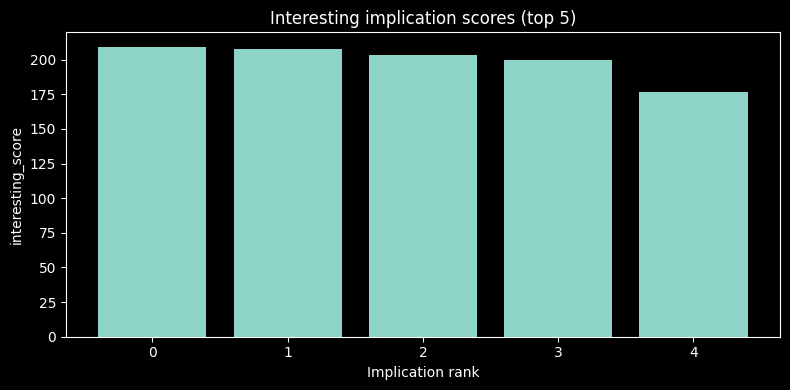

In [5]:
display(interesting_implications.head(5))

if len(interesting_implications) > 0:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(interesting_implications.head(5))), interesting_implications.head(5)["interesting_score"])
    plt.title("Interesting implication scores (top 5)")
    plt.xlabel("Implication rank")
    plt.ylabel("interesting_score")
    plt.tight_layout()
    plt.show()


## 5) Subgroups (binary targets + rationale)

Subgroups are mined as patterns that are highly precise for a **binary target**.

Detected subgroup files: `subgroups_high_price_quartile.csv`.

Rationale used in this run:
- `high_price_quartile`: Price in top quartile (>= 38.49) captures commercially premium wines.

Temporal-grouping policy:
- Prefer broad eras (e.g. <=2010 vs >2010) rather than tiny year-pairs (2001-2002, 2002-2003, ...)
- Reason: broader bins reduce sparsity and improve subgroup interpretability/stability


In [6]:
for csv_file in sorted(OUTPUT_DIR.glob("subgroups_*.csv")):
    print("\n===", csv_file.name, "===")
    df = pd.read_csv(csv_file)
    display(df.head(15))



=== subgroups_high_price_quartile.csv ===


,description,quality,tp,fp,support
0,{'Price': >= 4.99},0.3,3,7,10
1,{'ABV': <= 40.0},0.3,3,7,10
2,{'Vintage': >= 1999.0},0.3,3,7,10
3,{'ABV': >= 0.5},0.3,3,7,10
4,{'Price': <= 430.0},0.3,3,7,10
5,{'ABV': <= 14.5},0.3,3,7,10
6,{'Vintage': >= 2019.0},0.3,3,7,10
7,{'Vintage': <= 2023.0},0.3,3,7,10


## 6) Paspailleur Pattern Concepts (sampled run)

This section mirrors the pattern-mining spirit from the resource notebook but under lightweight constraints.


In [7]:
display(paspailleur_concepts.head(20))


,intent,support,delta_stability
0,"{'ABV': [0.5, 14.5], 'Country': NOT({'South Af...",10,NaN
1,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Ot...",9,NaN
2,"{'ABV': [0.5, 14.5], 'Country': NOT({'South Af...",9,NaN
3,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Ne...",9,NaN
4,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Ot...",9,NaN
5,"{'ABV': [12.5, 14.5], 'Country': NOT({'South A...",9,NaN
6,"{'ABV': [0.5, 14.5], 'Country': NOT({'South Af...",8,NaN
7,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Ot...",8,NaN
8,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Ot...",8,NaN
9,"{'ABV': [0.5, 14.5], 'Country': {'France', 'Au...",8,NaN


## 7) Practical Interpretation Notes

- Use top symbolic features as candidate explanatory variables for recommendation/ranking models.
- Validate highlighted implications with domain experts (oenologists/sommeliers).
- Subgroups should be re-mined on larger compute budgets if exhaustive subgroup quality optimization is required.
